Importing Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

Loading MNIST dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
type(X_train)

numpy.ndarray

In [4]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Training Images = 60,000 

Test Images = 10,000

Image Dimension = 28 x 28 

Grayscale Iamge = 1 channel

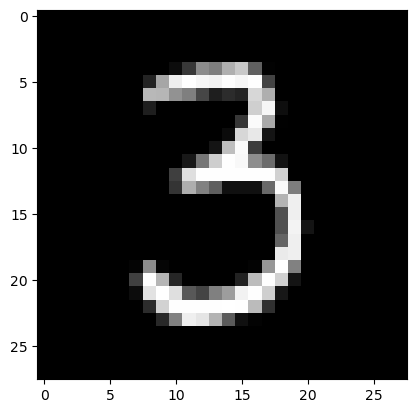

3


In [5]:
plt.imshow(X_train[50], cmap='gray')
plt.show()

print(y_train[50])

Image labels

In [6]:
print(y_train.shape, y_test.shape)

(60000,) (10000,)


In [7]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009]))


In [8]:
X_train = X_train / 255
X_test = X_test / 255

Building the Neural Network

In [9]:
# Setting up the layers of Neural Network
model = keras.Sequential([
    keras.layers.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

In [10]:
# Compiling the Neural Network
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [11]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 788us/step - accuracy: 0.9112 - loss: 0.3084
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - accuracy: 0.9564 - loss: 0.1465
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 737us/step - accuracy: 0.9675 - loss: 0.1067
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 740us/step - accuracy: 0.9747 - loss: 0.0840
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 747us/step - accuracy: 0.9796 - loss: 0.0686
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - accuracy: 0.9826 - loss: 0.0577
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - accuracy: 0.9853 - loss: 0.0491
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 752us/step - accuracy: 0.9877 - loss: 0.0415
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 751us/step - accuracy: 0.9891 - loss: 0.0364
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 740us/step - accuracy: 0.9900 - loss: 0.0319


Training data accuracy = 99.0%

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)
print(loss)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - accuracy: 0.9685 - loss: 0.1255
0.12551049888134003
0.968500018119812


Test data accuracy = 96.7%

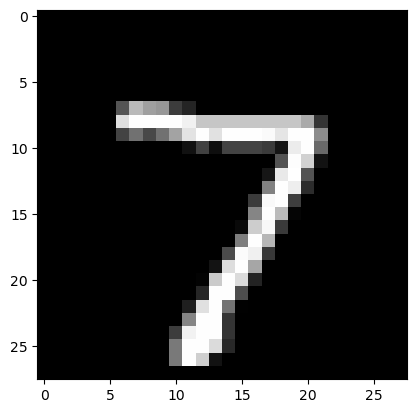

In [13]:
# First data point in X_test
plt.imshow(X_test[0], cmap='gray')
plt.show()

In [14]:
print(y_test[0])

7


In [15]:
y_pred = model.predict(X_test)
print(y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step
(10000, 10)


In [16]:
print(np.argmax(y_pred[0]))

7


model.predict() gives the prediction probability of each class for that data point

In [17]:
y_pred_labels = [np.argmax(i) for i in y_pred]

In [18]:
print(y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(8), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

y_test --> True labels

y_pred_labels --> Predicted labels

Confusion Matrix

In [19]:
conf_mat = confusion_matrix(y_test, y_pred_labels)

In [20]:
print(conf_mat)

tf.Tensor(
[[ 936    0    1    0    6    3    5    2    2   25]
 [   0 1116    1    3    4    1    4    1    5    0]
 [   2    2  983   13   10    0    2    9    9    2]
 [   1    0    1  976    2    5    1    7    9    8]
 [   0    0    2    0  966    0    8    0    0    6]
 [   2    0    0   12    2  863    5    1    6    1]
 [   6    2    1    1    3    4  940    0    0    1]
 [   1    3    8    3    1    0    1  999    2   10]
 [   5    0    0    2    5    2    4    2  946    8]
 [   0    2    0    5   33    3    0    3    3  960]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted Labels')

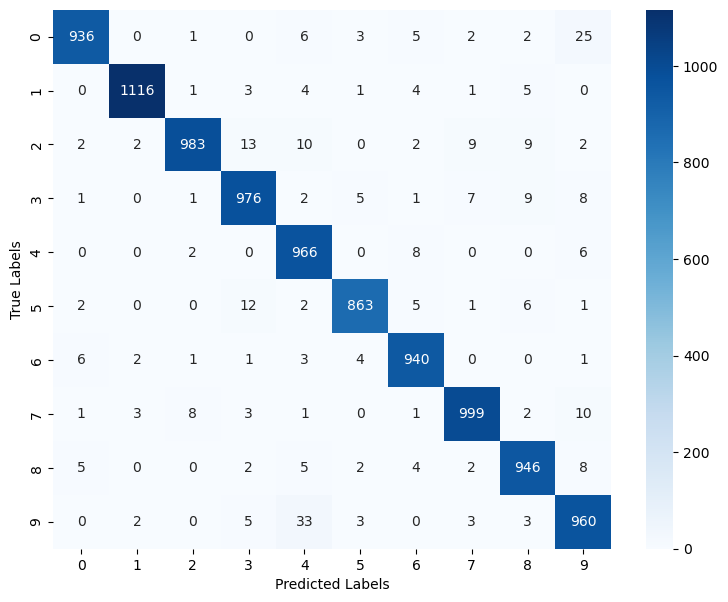

In [21]:
plt.figure(figsize=(9,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

Building Predictive System

In [22]:
img_path = r"C:\Users\user\Downloads\MNIST_digit.png"
img = cv2.imread(img_path)

In [23]:
type(img)

numpy.ndarray

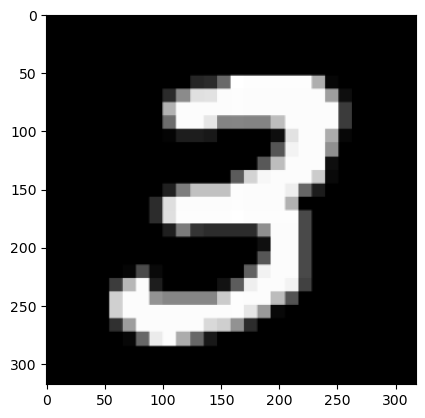

In [24]:
plt.imshow(img)
plt.show()

In [25]:
img.shape

(318, 318, 3)

In [26]:
grayscale_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

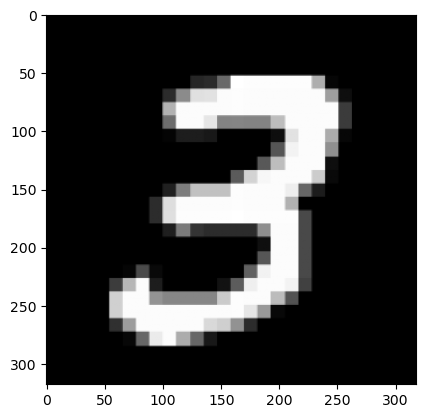

In [27]:
plt.imshow(grayscale_img, 'gray')
plt.show()

In [28]:
input_img_resized = cv2.resize(grayscale_img, (28,28))

In [29]:
input_img_resized.shape

(28, 28)

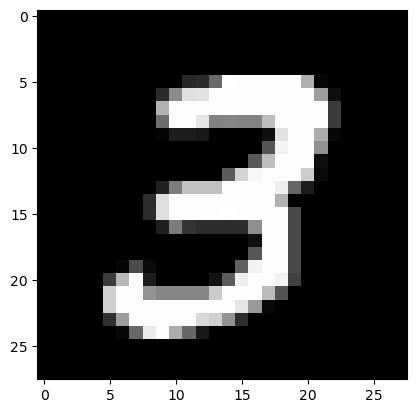

In [30]:
plt.imshow(input_img_resized, 'gray')
plt.show()

In [31]:
input_img_resized = input_img_resized/255

In [32]:
image_reshaped = np.reshape(input_img_resized, [1, 28, 28])

In [33]:
image_reshaped.shape

(1, 28, 28)

In [34]:
input_pred = model.predict(image_reshaped)
input_pred_label = np.argmax(input_pred)

print(f'Prediction for input image is {input_pred_label}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction for input image is 3


**Predictive System**

In [35]:
img_path = input('Path for the image to be predicted: ').strip('"')
img = cv2.imread(img_path)

grayscale_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
input_img_resized = cv2.resize(grayscale_img, (28,28))
input_img_resized = input_img_resized/255
image_reshaped = np.reshape(input_img_resized, [1, 28, 28])

input_pred = model.predict(image_reshaped)
input_pred_label = np.argmax(input_pred)

print(f'Prediction for input image is {input_pred_label}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Prediction for input image is 3
